Computational Physics numerical algorithm (ODE)

In [ ]:
#Euler's method
from math import sin
from numpy import arange
from pylab import plot,xlabel,ylabel,show

def f(x,t):
  return -x**3+sin(t)

a=0.0 #구간 시작
b=10.0 #구간 끝
N=1000 #스텝 수
h=(b-a)/N #스텝 사이즈
x=0.0 #초기 상태 설정

tpoints=arange(a,b,h)
xpoints=[]
for t in tpoints:
  xpoints.append(x)
  x=x+h*f(x,t)

plot(tpoints,xpoints)
xlabel('t')
ylabel('x')
show()

In [ ]:
#Scipy를 이용
from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt


def f(t,x):
  return -x**3+np.sin(t)

sol=solve_ivp(f,[0,10],(0,))
plt.plot(sol.t,sol.y[0]) # 'sol.x' 대신 'sol.y[0]' 사용
plt.xlabel('t')
plt.ylabel('x')
plt.show()

In [ ]:
#룽게-쿠타 방법
from math import sin
from numpy import arange
from pylab import plot,xlabel,ylabel,show

def f(x,t):
  return -x**3+sin(t)

a=0.0
b=10.0
N=10000
h=(b-a)/N

tpoints_RK2=arange(a,b,h)
xpoints_RK2=[]

x=0.0 #초기 상태 설정
for t in tpoints:
  xpoints_RK2.append(x)
  k1=h*f(x,t)
  k2=h*f(x+0.5*k1,t+0.5*h)
  x+=k2

plot(tpoints_RK2,xpoints_RK2)
xlabel('t')
ylabel('x')
show()

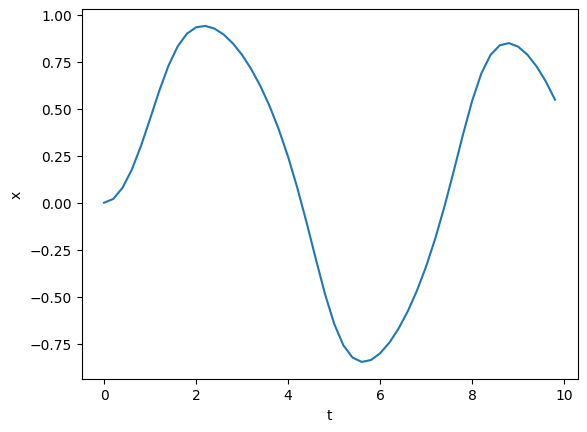

In [ ]:
from math import sin
from numpy import arange
from pylab import plot,xlabel,ylabel,show

def f(x,t):
  return -x**3+sin(t)

a=0.0
b=10.0
N=50
h=(b-a)/N

tpoints_RK4=arange(a,b,h)
xpoints_RK4=[]

x=0.0
for t in tpoints_RK4:
  xpoints_RK4.append(x)
  k1=h*f(x,t)
  k2=h*f(x+0.5*k1,t+0.5*h)
  k3=h*f(x+0.5*k2,t+0.5*h)
  k4=h*f(x+k3,t+h)
  x+=k1/6+k2/3+k3/3+k4/6

plot(tpoints_RK4,xpoints_RK4)
xlabel('t')
ylabel('x')
show()

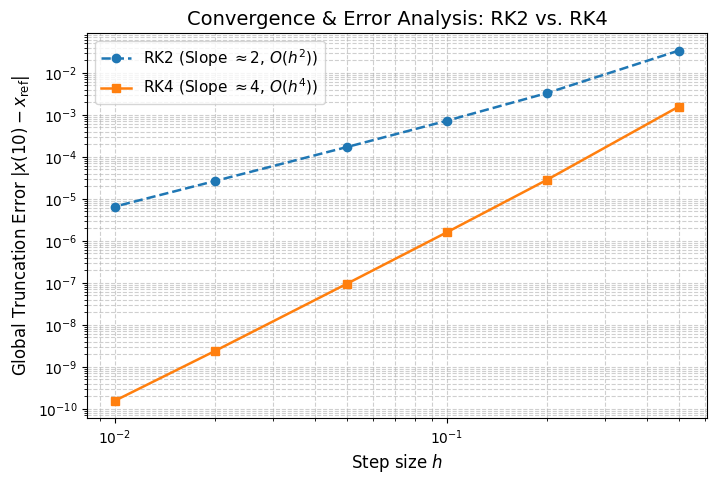

In [15]:
#룽게-쿠타 방법의 2차와 4차 비교
import matplotlib.pyplot as plt
import numpy as np


# 1. 대상 미분방정식 정의
def f(x, t):
  return -(x**3) + np.sin(t)


# 2. RK2 솔버 (목표 시점 t_end에서의 x값 반환)
def solve_rk2(f, x0, t0, t_end, N):
  h = (t_end - t0) / N
  x = x0
  t = t0
  for _ in range(N):
    k1 = h * f(x, t)
    k2 = h * f(x + 0.5 * k1, t + 0.5 * h)
    x += k2
    t += h
  return x


# 3. RK4 솔버 (목표 시점 t_end에서의 x값 반환)
def solve_rk4(f, x0, t0, t_end, N):
  h = (t_end - t0) / N
  x = x0
  t = t0
  for _ in range(N):
    k1 = h * f(x, t)
    k2 = h * f(x + 0.5 * k1, t + 0.5 * h)
    k3 = h * f(x + 0.5 * k2, t + 0.5 * h)
    k4 = h * f(x + k3, t + h)
    x += (k1 + 2 * k2 + 2 * k3 + k4) / 6
    t += h
  return x


# 4. 시뮬레이션 설정 및 참값(Reference) 계산
x0 = 0.0
t0 = 0.0
t_end = 10.0

# 스텝 수를 매우 크게 잡은(N=200,000) 고정밀 RK4 결과를 참값으로 설정
x_exact = solve_rk4(f, x0, t0, t_end, N=200000)

# 비교할 스텝 수(N)와 스텝 크기(h) 배열
N_values = [20, 50, 100, 200, 500, 1000]
h_values = [(t_end - t0) / N for N in N_values]

errors_rk2 = []
errors_rk4 = []

for N in N_values:
  x_rk2 = solve_rk2(f, x0, t0, t_end, N)
  x_rk4 = solve_rk4(f, x0, t0, t_end, N)

  errors_rk2.append(abs(x_rk2 - x_exact))
  errors_rk4.append(abs(x_rk4 - x_exact))

# 5. Log-Log 스케일 오차 비교 그래프 시각화
plt.figure(figsize=(8, 5))
plt.loglog(
    h_values,
    errors_rk2,
    "o--",
    label=r"RK2 (Slope $\approx 2, \, O(h^2)$)",
    linewidth=1.8,
)
plt.loglog(
    h_values,
    errors_rk4,
    "s-",
    label=r"RK4 (Slope $\approx 4, \, O(h^4)$)",
    linewidth=1.8,
)

plt.xlabel(r"Step size $h$", fontsize=12)
plt.ylabel(r"Global Truncation Error $|x(10) - x_{\mathrm{ref}}|$", fontsize=12)
plt.title("Convergence & Error Analysis: RK2 vs. RK4", fontsize=14)
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.legend(fontsize=11)
plt.show()

In [ ]:
#룽게-쿠타방법을 이용한 저주파필터
import numpy as np
import matplotlib.pyplot as plt

def floor(t):
  return (2*t)//1

def v_in(t):
  if floor(t)%2==0:
    return 1
  if floor(t)%2==1:
    return -1

def dvdt(v_out,t):
  RC=1
  return (v_in(t)-v_out)/RC

a=0.0
b=10.0
N=10000
h=(b-a)/N

tpoints=np.arange(a,b,h)
voutpoints=[]
v_out=0.0
for t in tpoints:
  voutpoints.append(v_out)
  k1=h*dvdt(v_out,t)
  k2=h*dvdt(v_out+0.5*k1,t+0.5*h)
  k3=h*dvdt(v_out+0.5*k2,t+0.5*h)
  k4=h*dvdt(v_out+k3,t+h)
  v_out+=(k1+2*k2+2*k3+k4)/6

plt.plot(tpoints,voutpoints,label='')
plt.xlabel('t')
plt.ylabel('v_out')
plt.title('A low-pass filter')
plt.show()


In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

def floor(t):
  return (2*t)//1

def v_in(t):
  if floor(t)%2==0:
    return 1
  if floor(t)%2==1:
    return -1

def dvdt(v_out,t):
  RC=0.01
  return (v_in(t)-v_out)/RC

v_out=0.0
sol=solve_ivp(dvdt,[0,10],[v_out],method='RK45')
plt.plot(sol.t,sol.y[0])
plt.xlabel('t')
plt.ylabel('v_out')

In [ ]:
# Solutions Over Infinite Ranges
from numpy import arange
from pylab import plot,xlabel,ylabel,xlim,show

def g(x,u):
  return 1/(x**2*(1-u)**2+u**2)

a=0.0
b=80.0
N=100
h=(b-a)/N

upoints=arange(a,b,h)
tpoints=[]
xpoints=[]
for u in upoints:
  tpoints.append(u/(1-u))
  xpoints.append(x)
  k1=h*g(x,u)
  k2=h*g(x+0.5*k1,u+0.5*h)
  k3=h*g(x+0.5*k2,u+0.5*h)
  k4=h*g(x+k3,u+h)
  x+=k1/6+k2/3+k3/3+k4/6

plot(upoints,xpoints)
xlabel('u')
ylabel('x')
show()


In [ ]:
#Simultaneous Ordinary Differential Equations
from math import sin
from numpy import array,arange
from pylab import plot,xlabel,show

def f(r,t):
  x=r[0]
  y=r[1]
  fx=x*y-x
  fy=y-x*y+sin(t)**2
  return array([fx,fy],float)

a=0.0
b=10.0
N=1000
h=(b-a)/N

tpoints=arange(a,b,h)
xpoints=[]
ypoints=[]
r=array([1.0,1.0],float)
for t in tpoints:
  xpoints.append(r[0])
  ypoints.append(r[1])
  k1=h*f(r,t)
  k2=h*f(r*0.5+k1,t+0.5*h)
  k3=h*f(r*0.5+k2,t+0.5*h)
  k4=h*f(r+k3,t+h)
  r+=(k1+2*k2+2*k3+k4)/6
plot(tpoints,xpoints)
plot(tpoints,ypoints)
xlabel('t')
show()

In [ ]:
#The Lotka-Volterra equations
import numpy as np
import matplotlib.pyplot as plt

def f(r,t,a,b,g,d):
  x=r[0]
  y=r[1]
  fx=a*x-b*x*y
  fy=g*x*y-d*y
  return np.array([fx,fy],float)

a=0.0
b=30.0
N=1000
h=(b-a)/N

tpoints=np.arange(a,b,h)
xpoints=[]
ypoints=[]

r=np.array([2.0,2.0],float)
for t in tpoints:
  xpoints.append(r[0])
  ypoints.append(r[1])
  k1=h*f(r,t,1,0.5,0.5,2)
  k2=h*f(r*0.5+k1,t+0.5*h,1,0.5,0.5,2)
  k3=h*f(r*0.5+k2,t+0.5*h,1,0.5,0.5,2)
  k4=h*f(r*k3,t+h,1,0.5,0.5,2)
  r+=(k1+2*k2+2*k3+k4)/6

plt.plot(tpoints,xpoints,label='Prey')
plt.plot(tpoints,ypoints,label='Predator')
plt.xlabel('t')
plt.ylabel('population')
plt.title('Lotka-Volterra Dynamics')
plt.legend()
plt.show()



In [ ]:
#second-order differential equations
import numpy as np
import matplotlib.pyplot as plt

g=9.81
l=0.1

def f(r,t):
  theta=r[0]
  omega=r[1]
  ftheta=omega
  fomega=-(g/l)*np.sin(theta)
  return np.array([ftheta,fomega],float)


a=0.0
b=10.0
N=1000
h=(b-a)/N

tpoints=np.arange(a,b,h)
thetapoints=[]
omegapoints=[]
r=np.array([179*(np.pi/180),0.0],float)
for t in tpoints:
  thetapoints.append(r[0])
  omegapoints.append(r[1])
  k1=h*f(r,t)
  k2=h*f(r+0.5*k1,t+0.5*h)
  k3=h*f(r+0.5*k2,t+0.5*h)
  k4=h*f(r+k3,t+h)
  r+=(k1+2*k2+2*k3+k4)/6

ax1=plt.subplot(2,1,1)
plt.plot(tpoints,thetapoints,label='theta')
plt.title("pendulum's theta")

ax2=plt.subplot(2,1,2)
plt.plot(tpoints,omegapoints,label='omega')
plt.xlabel('pendulums omega')

plt.show()







In [ ]:
#the simple pendulum animation(처음 각도 theta=179°)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

l=0.1

xpoints=l*np.sin(thetapoints)
ypoints=-l*np.cos(thetapoints)

fig,ax=plt.subplots()
ax.set_xlim(-0.4,0.4)
ax.set_ylim(-0.4,0.4)
ax.grid(True)

line,=ax.plot([],[],'k-',lw=2)
point,=ax.plot([],[],'ro',ms=10)

def update(i):
  cx=xpoints[i]
  cy=ypoints[i]
  line.set_data([0,cx],[0,cy])
  point.set_data([cx],[cy])
  return line, point

ani=FuncAnimation(fig,update,frames=len(tpoints),interval=20)

HTML(ani.to_jshtml())



In [ ]:
#The driven pendulum(구동력이 포함된 단진자 운동)
import numpy as np
import matplotlib.pyplot as plt


g=9.8
l=10

def f(x,t):
  theta=x[0]
  omega=x[1]
  ftheta=omega
  fomega=-(g/l)*np.sin(theta)+2*np.cos(theta)*np.sin(10*t)
  return np.array([ftheta,fomega],float)

a=0.0
b=100.0
N2=1000
h2=(b-a)/N2
s=np.array([0,0],float)

tpoints2=np.arange(a,b,h2)
thetapoints2=[]
omegapoints2=[]

for t in tpoints2:
  thetapoints2.append(s[0])
  omegapoints2.append(s[1])
  k1=h2*f(s,t)
  k2=h2*f(s+0.5*k1,t+0.5*h2)
  k3=h2*f(s+0.5*k2,t+0.5*h2)
  k4=h2*f(s+k3,t+h2)
  s+=(k1+k2*2+k3*2+k4)/6

plt.plot(tpoints2,thetapoints2,label='')
plt.xlabel('t')
plt.ylabel('theta')
plt.title("Movement of Driven Pendulum")
plt.show()


In [ ]:
#구동력이 추가된 단진자 애니메이션
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

l=10

xpoints2=l*np.sin(thetapoints2)
ypoints2=-l*np.cos(thetapoints2)

fig,ax=plt.subplots()
ax.set_xlim(-15,15)
ax.set_ylim(-15,15)
ax.grid(True)

line,=ax.plot([],[],'k-',lw=2)
ball,=ax.plot([],[],'ro',ms=10)

def update_d(i):
  cx_d=xpoints2[i]
  cy_d=ypoints2[i]
  line.set_data([0,cx_d],[0,cy_d])
  ball.set_data([cx_d],[cy_d])
  return line, ball

ani=FuncAnimation(fig,update_d,frames=len(tpoints2),interval=20)

HTML(ani.to_jshtml())


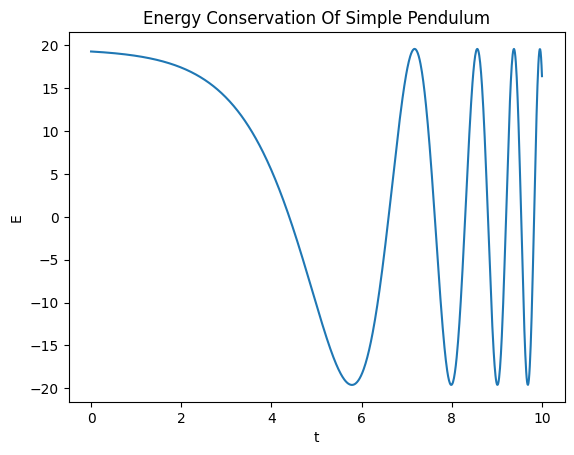

In [19]:
#리프록 알고리즘
import numpy as np
import matplotlib.pyplot as plt

g=9.8
l=1.0
m=2.0

def f(x,t):
  theta,omega=x
  ftheta=omega
  fomega=-(g/l)*np.sin(theta)
  return np.array([theta,omega])
def leafrog(f,x,xm,t,h):
  x1=x+0.5*h*f(x,t+0.5*h)
  xm1=xm+0.5*h*f(x1,t+h)
  return x1,xm1
def RK4(f,x,t,h):
  k1=h*f(x,t)
  k2=h*f(x+0.5*k1,t+0.5*h)
  k3=h*f(x+0.5*k2,t+0.5*h)
  k4=h*f(x+k3,t+h)
  x+=(k1+k2*2+k3*2+k4)/6
  return x

N=1000
Tmax=10
t=np.linspace(0,Tmax,N)
s=np.zeros((N,2))
E_list=[]
s[0,0]=np.radians(10)
h=t[1]-t[0]

sm=np.zeros_like(s)
sm[0]=RK4(f,s[0],t[0],0.5*h)

for i in range(N-1):
  s[i+1],sm[i+1]=leafrog(f,s[i],sm[i],t[i],h)

for j in range(N):
  E=0.5*m*s[:,1][j]**2+m*g*l*np.cos(s[:,0][j])
  E_list.append(E)


plt.plot(t,E_list) #에너지 보존 확인
plt.xlabel('t')
plt.ylabel('E')
plt.title("Energy Conservation Of Simple Pendulum")
plt.show()



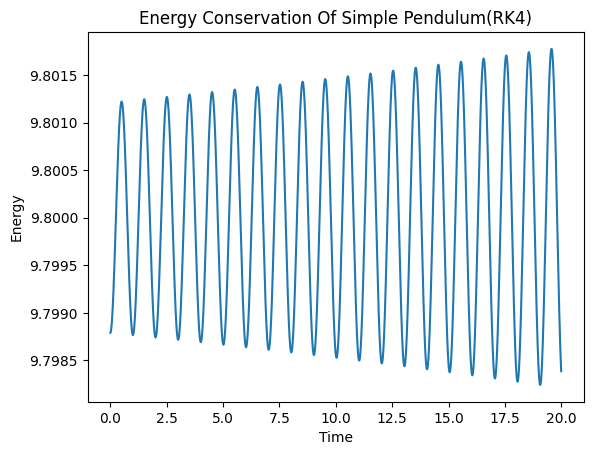

In [17]:
import numpy as np
import matplotlib.pyplot as plt

g=9.8
l=1.0
m=1.0

def f(x,t):
  theta,omega=x
  ftheta=omega
  fomega=-(g/l)*np.sin(theta)
  return np.array([ftheta, fomega], float)
def Euler(f,x,t,h):
  x+=h*f(x,t)
  return x

N=10000
Tmax=20.0
t=np.linspace(0,Tmax,N)
s=np.zeros((N,2))
E_list=[]
s[0,0]=np.pi/200.0
h=t[1]-t[0]

for i in range(N-1):
  s[i+1]=Euler(f,s[i],t[i],h)
for j in range(N):
  E=0.5*m*s[:,1][j]**2+m*g*l*np.cos(s[:,0][j])
  E_list.append(E)

plt.plot(t,E_list)
plt.xlabel('Time')
plt.ylabel('Energy')
plt.title('Energy Conservation Of Simple Pendulum(RK4)')
plt.show()
#오일러방법의 한계: 에너지는 보존이 불가하다.

In [ ]:
#verlet정리를 이용한 행성궤도운동(예시)
import numpy as np
import matplotlib.pyplot as plt

def verlet(f,p,x,h):
  p+=0.5*h*f(x)
  x+=h*p
  p+=0.5*h*f(x)
  return x,p

def f(x):
  rinv=np.sum(x**2)**(-1.5)
  return -x*rinv

vi=1
x0=np.array([1,0])
p0=np.array([0,vi])
ecc=1.0-(vi)**2 #이심률의 범위는 0<ecc<1
T=2.0*np.pi*(1.0+ecc)**(-1.5)
h=0.001
t=np.arange(0,min(T,100),h)

x=np.zeros((t.size,2))
p=np.zeros_like(x)
x[0]=x0
p[0]=p0

for i in range(t.size-1):
  x[i+1],p[i+1]=verlet(f,p[i],x[i],h)

plt.plot(x[:,0],x[:,1],lw=1,label='Orbit')
plt.plot([0],[0],'ro',label='Planet')
plt.ylim(-2.0,2.0)
plt.axis('equal')
plt.legend()
plt.title('The Orbit of Planet')
plt.show()
